# Proyecto: predicción de la recuperación del oro (Zyfra)

## Objetivo general

Construir un modelo que prediga la cantidad de oro recuperada a partir del mineral en bruto, usando los datos de extracción y purificación de la planta. El modelo debe estimar dos objetivos: la recuperación del proceso de flotación (rougher.output.recovery) y la recuperación final tras la purificación (final.output.recovery), y se evalúa con el sMAPE final, que pondera ambos objetivos.

### Descripción de los datos

Los datos vienen en tres archivos, cuyos índices son las fecha y hora de adquisición.

- gold_recovery_train.csv: conjunto de entrenamiento.
- gold_recovery_test.csv: conjunto de prueba
- gold_recovery_full.csv: conjunto fuente (Train + test)

Los nombres de las columnas tienen la estructura "etapa.tipo_de_parámetro.nombre." Las etapas son rougher (flotación), primary_cleaner y secondary_cleaner (purificación) y final (características finales). Los tipos son input (parámetros de la materia prima), output (parámetros del producto), state (parámetros que caracterizan la etapa) y calculation (características calculadas).

## 1. Preparación de los datos

### 1.1 Abre los archivos y examina los datos

**Objetivo:** cargar los tres archivos, comprobar su tamaño, el período que cubren y el estado general de los datos (duplicados y valores ausentes

In [1]:
# Importamos las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats 

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer

# mostramos todas las columnas al imprimir los DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [2]:
def cargar_datos(nombre_archivo):
    try:
        datos = pd.read_csv(nombre_archivo, parse_dates=['date'])   # ruta local
    except FileNotFoundError:
        datos = pd.read_csv(f'/datasets/{nombre_archivo}', parse_dates=['date'])   # ruta de la plataforma
    return datos


# cargamos los tres archivos y los guardamos en un diccionario para recorrerlos después
train = cargar_datos('gold_recovery_train.csv')
test = cargar_datos('gold_recovery_test.csv')
full = cargar_datos('gold_recovery_full.csv')

conjuntos = {'entrenamiento': train, 'prueba': test, 'fuente': full}

In [3]:
# Revisamos la estructura de cada conjunto: tamaño, período cubierto, duplicados y ausentes
filas_resumen = []

for nombre, datos in conjuntos.items():
    filas_resumen.append(
        {
            'conjunto': nombre,
            'filas': datos.shape[0],
            'columnas': datos.shape[1],
            'fecha_min': datos['date'].min(),
            'fecha_max': datos['date'].max(),
            'fechas_duplicadas': datos['date'].duplicated().sum(),
            'filas_duplicadas': datos.duplicated().sum(),
            'columnas_con_ausentes': (datos.isna().sum() > 0).sum(),
            'celdas_ausentes': datos.isna().sum().sum(),
            'pct_filas_completas': round(100 * datos.notna().all(axis=1).mean(), 2),
        }
    )

resumen = pd.DataFrame(filas_resumen).set_index('conjunto')
resumen.T # Transponemos el dataframe para faciltar la visualización

conjunto,entrenamiento,prueba,fuente
filas,16860,5856,22716
columnas,87,53,87
fecha_min,2016-01-15 00:00:00,2016-09-01 00:59:59,2016-01-15 00:00:00
fecha_max,2018-08-18 10:59:59,2017-12-31 23:59:59,2018-08-18 10:59:59
fechas_duplicadas,0,0,0
filas_duplicadas,0,0,0
columnas_con_ausentes,85,51,85
celdas_ausentes,30320,2360,36587
pct_filas_completas,65.34,91.92,70.85


In [4]:
# Comprobamos cómo se reparten los períodos: ¿Existe overlapping entre test y train?, ¿full los contiene a los dos?
print('Fechas compartidas entre entrenamiento y prueba:', len(set(train['date']) & set(test['date'])))
print('Todas las fechas de prueba están en el conjunto fuente:', test['date'].isin(full['date']).all())
print('Todas las fechas de entrenamiento están en el conjunto fuente:', train['date'].isin(full['date']).all())
print('Filas de entrenamiento + prueba:', len(train) + len(test), '| filas del conjunto fuente:', len(full))

# frecuencia de muestreo: diferencia en horas entre registros consecutivos
intervalos = full.sort_values('date')['date'].diff().dt.total_seconds() / 3600
print()
print('Intervalo entre registros consecutivos (horas):')
print(intervalos.value_counts().head())

Fechas compartidas entre entrenamiento y prueba: 0
Todas las fechas de prueba están en el conjunto fuente: True
Todas las fechas de entrenamiento están en el conjunto fuente: True
Filas de entrenamiento + prueba: 22716 | filas del conjunto fuente: 22716

Intervalo entre registros consecutivos (horas):
date
1.000000    22714
0.999722        1
Name: count, dtype: int64


In [5]:
# Vemos qué columnas concentran los valores ausentes en el conjunto de entrenamiento
ausentes_train = (100 * train.isna().mean()).sort_values(ascending=False)
ausentes_train.head(10).round(2)

rougher.output.recovery               15.26
rougher.output.tail_ag                13.35
rougher.output.tail_sol               13.34
rougher.output.tail_au                13.34
secondary_cleaner.output.tail_sol     11.78
rougher.input.floatbank11_xanthate    11.29
final.output.recovery                  9.02
primary_cleaner.input.sulfate          7.75
primary_cleaner.input.depressant       7.49
rougher.calculation.au_pb_ratio        7.37
dtype: float64

**Conclusión:** los tres archivos se cargaron correctamente y 'date' quedó como fecha. El conjunto de entrenamiento tiene 16 860 filas y 87 columnas, el de prueba 5 856 filas y solo 53 columnas, y el fuente 22 716 filas con las 87 columnas. Las cuentas cuadran de forma exacta: 16 860 + 5 856 = 22 716, no hay ninguna fecha compartida entre entrenamiento y prueba, y todas las fechas de ambos aparecen en el conjunto fuente. Es decir, el fuente es la unión de los otros dos, y la partición se hizo por período, no al azar: prueba cubre del 2016-09-01 al 2017-12-31, una ventana continua dentro del rango total (2016-01-15 a 2018-08-18)

No hay filas ni fechas duplicadas en ningún conjunto, y el muestreo es horario: 22 714 de los 22 715 intervalos entre registros consecutivos son de exactamente una hora.

Los valores ausentes sí son un problema de peso: afectan a 85 de las 87 columnas del entrenamiento y solo el 65.34 % de sus filas están completas (91.92 % en prueba). No se concentran en unas pocas columnas rotas, sino que están repartidos en dosis pequeñas por casi todas; la peor es 'rougher.output.recovery' con 15.26 %, seguida de las colas del rougher con ~13%. Eliminar toda fila con algún ausente costaría más de un tercio del conjunto de entrenamiento, evaluaremos alguna forma de rellenas los campos que se puedan llenar

### 1.2 Comprueba que el cálculo de la recuperación sea correcto

**Objetivo:** comprobar que la columna 'rougher.output.recovery' del dataset está bien calculada, replicando la fórmula de recuperación sobre el conjunto de entrenamiento y midiendo el Error Absoluto Medio (EAM) entre nuestro cálculo y los valores del archivo.

La recuperación se calcula como:

$$\text{Recovery} = \frac{C \times (F - T)}{F \times (C - T)} \times 100\%$$

donde, para la etapa de flotación y el oro:

- $C$ = 'rougher.output.concentrate_au', proporción de oro en el concentrado justo después de la flotación.
- $F$ = 'rougher.input.feed_au', proporción de oro en la alimentación antes de la flotación.
- $T$ = 'rougher.output.tail_au', proporción de oro en las colas justo después de la flotación.

In [6]:
# Replicamos la fórmula de recuperación sobre el conjunto de entrenamiento
C = train['rougher.output.concentrate_au']
F = train['rougher.input.feed_au']
T = train['rougher.output.tail_au']

denominador = F * (C - T)
recovery_calculada = C * (F - T) / denominador * 100

# cuando no hay material el denominador es cero y la recuperación no está definida
recovery_calculada[denominador == 0] = np.nan

# comparamos solo en las filas donde tenemos las dos versiones del valor
comparables = recovery_calculada.notna() & train['rougher.output.recovery'].notna()
diferencias = (recovery_calculada[comparables] - train.loc[comparables, 'rougher.output.recovery']).abs()

print('Filas comparables:', comparables.sum(), 'de', len(train))
print('EAM entre el cálculo propio y la columna del dataset:', diferencias.mean())
print('Diferencia absoluta máxima:', diferencias.max())

Filas comparables: 14287 de 16860
EAM entre el cálculo propio y la columna del dataset: 9.210911277458828e-15
Diferencia absoluta máxima: 7.105427357601002e-14


In [7]:
# Revisamos las filas que no pudimos comparar: ¿el dataset sí trae un valor donde nuestro cálculo falla?
no_comparables = ~comparables
print('Filas no comparables:', no_comparables.sum())
print('De ellas, con recovery presente en el dataset:', (no_comparables & train['rougher.output.recovery'].notna()).sum())

Filas no comparables: 2573
De ellas, con recovery presente en el dataset: 0


**Conclusión:** la fórmula del dataset es correcta. Sobre las 14 287 filas donde se pueden comparar las dos versiones, el EAM es de 9.21e-15 y la diferencia máxima de 7.11e-14: son errores de redondeo, no discrepancias reales. La columna 'rougher.output.recovery' puede usarse, como está, como objetivo.

### 1.3 Analiza las características no disponibles en el conjunto de prueba

**Objetivo:** identificar qué columnas están en el conjunto de entrenamiento pero no en el de prueba, cuáles son esos parámetros y de qué tipo son, para delimitar con cuáles se puede entrenar realmente el modelo.

In [8]:
# Localizamos las columnas que están en entrenamiento pero no en prueba y las clasificamos
faltantes = []

for columna in train.columns:
    if columna not in test.columns:
        faltantes.append(columna)

info_faltantes = pd.DataFrame({'columna': faltantes})
info_faltantes['etapa'] = info_faltantes['columna'].str.split('.').str[0]
info_faltantes['tipo'] = info_faltantes['columna'].str.split('.').str[1]

print('Columnas ausentes en el conjunto de prueba:', len(faltantes))
print('Tipos de dato:', train[faltantes].dtypes.unique())
print()
print(pd.crosstab(info_faltantes['etapa'], info_faltantes['tipo'], margins=True))

Columnas ausentes en el conjunto de prueba: 34
Tipos de dato: [dtype('float64')]

tipo               calculation  output  All
etapa                                      
final                        0       9    9
primary_cleaner              0       8    8
rougher                      4       9   13
secondary_cleaner            0       4    4
All                          4      30   34


In [9]:
# Listamos las columnas faltantes agrupadas por tipo de parámetro
for tipo in info_faltantes['tipo'].unique():
    columnas_tipo = info_faltantes[info_faltantes['tipo'] == tipo]['columna']
    print('---', tipo, '(', len(columnas_tipo), 'columnas )---')
    for columna in columnas_tipo:
        print('  ', columna)

--- output ( 30 columnas )---
   final.output.concentrate_ag
   final.output.concentrate_pb
   final.output.concentrate_sol
   final.output.concentrate_au
   final.output.recovery
   final.output.tail_ag
   final.output.tail_pb
   final.output.tail_sol
   final.output.tail_au
   primary_cleaner.output.concentrate_ag
   primary_cleaner.output.concentrate_pb
   primary_cleaner.output.concentrate_sol
   primary_cleaner.output.concentrate_au
   primary_cleaner.output.tail_ag
   primary_cleaner.output.tail_pb
   primary_cleaner.output.tail_sol
   primary_cleaner.output.tail_au
   rougher.output.concentrate_ag
   rougher.output.concentrate_pb
   rougher.output.concentrate_sol
   rougher.output.concentrate_au
   rougher.output.recovery
   rougher.output.tail_ag
   rougher.output.tail_pb
   rougher.output.tail_sol
   rougher.output.tail_au
   secondary_cleaner.output.tail_ag
   secondary_cleaner.output.tail_pb
   secondary_cleaner.output.tail_sol
   secondary_cleaner.output.tail_au
--- calcula

In [10]:
# Las columnas comunes a los dos conjuntos son las únicas que pueden servir como características
comunes = []

for columna in train.columns:
    if columna in test.columns and columna != 'date':
        comunes.append(columna)

info_comunes = pd.DataFrame({'columna': comunes})
info_comunes['tipo'] = info_comunes['columna'].str.split('.').str[1]

print('Características disponibles en ambos conjuntos:', len(comunes))
print()
print(info_comunes['tipo'].value_counts())

Características disponibles en ambos conjuntos: 52

tipo
state    38
input    14
Name: count, dtype: int64


**Conclusión:** faltan 34 columnas en el conjunto de prueba, todas de tipo 'float64'. No es un subconjunto arbitrario: son 30 columnas 'output' y 4 columnas 'calculation'. por lo que veo, ninguna de tipo 'input' o 'state'. Repartidas por etapa quedan 13 en 'rougher' (9 'output' + 4 'calculation'), 9 en 'final', 8 en 'primary_cleaner' y 4 en 'secondary_cleaner'.

El patrón tiene sentido físico: lo que falta es todo lo que se conoce después del proceso. las concentraciones de los concentrados y de las colas, los ratios calculados, y las dos recuperaciones. Son parámetros que se miden en laboratorio o se calculan mucho más tarde, y parece que por eso no están disponibles en el momento en que el modelo tendría que hacer la predicción. Entre ellas están los dos objetivos, 'rougher.output.recovery' y 'final.output.recovery', que habrá que recuperar del conjunto fuente a travé de 'date' para poder evaluar la prueba.

Quedan 52 características utilizables, comunes a ambos conjuntos: 38 de tipo 'state' (parámetros de operación de la planta) y 14 de tipo input (características de la materia prima y reactivos). Ese es el conjunto de features con el que se entrenará el modelo. Usar cualquiera de las 34 restantes sería una fuga de información: el modelo aprendería del resultado que se le pide predecir.

### 1.4 Realiza el preprocesamiento de datos

**Objetivo:** dejar las 52 características utilizables sin valores ausentes, sin eliminar filas de ninguno de los dos conjuntos, y decidir por separado qué hacer con los ausentes de los objetivos.

In [11]:
# Ordenamos por fecha: el relleno de ausentes solo tiene sentido si sigue el orden temporal
train = train.sort_values('date').reset_index(drop=True)
test = test.sort_values('date').reset_index(drop=True)

# guardamos cuántos ausentes y cuántas filas hay antes de rellenar, para comparar después
ausentes_antes = {}
filas_antes = {}

for nombre, datos in [('entrenamiento', train), ('prueba', test)]:
    ausentes = datos[comunes].isna().sum().sum()
    celdas = len(datos) * len(comunes)
    filas_afectadas = datos[comunes].isna().any(axis=1).sum()

    ausentes_antes[nombre] = ausentes
    filas_antes[nombre] = len(datos)

    print(nombre, ':', ausentes, 'celdas ausentes de', celdas,
          '(', round(100 * ausentes / celdas, 2), '%)',
          'repartidas en', filas_afectadas, 'filas')

entrenamiento : 12668 celdas ausentes de 876720 ( 1.44 %) repartidas en 3338 filas
prueba : 2360 celdas ausentes de 304512 ( 0.78 %) repartidas en 473 filas


In [12]:
# Rellenamos hacia adelante (última medición conocida) y hacia atrás solo para los huecos
# que caen al principio de la serie. No se elimina ninguna fila.
train[comunes] = train[comunes].ffill().bfill()
test[comunes] = test[comunes].ffill().bfill()

for nombre, datos in [('entrenamiento', train), ('prueba', test)]:
    print(nombre, ': ausentes en las features', ausentes_antes[nombre], '->', datos[comunes].isna().sum().sum(),
          '| filas', filas_antes[nombre], '->', len(datos))

entrenamiento : ausentes en las features 12668 -> 0 | filas 16860 -> 16860
prueba : ausentes en las features 2360 -> 0 | filas 5856 -> 5856


In [13]:
# Los objetivos no se rellenan para no sesgar las predicciones
# Esas filas se excluyen al armar el conjunto de cada modelo, no se borran del DataFrame.
objetivos = ['rougher.output.recovery', 'final.output.recovery']

for objetivo in objetivos:
    print(objetivo, ':', train[objetivo].isna().sum(), 'ausentes |',
          train[objetivo].notna().sum(), 'filas utilizables para entrenar')

rougher.output.recovery : 2573 ausentes | 14287 filas utilizables para entrenar
final.output.recovery : 1521 ausentes | 15339 filas utilizables para entrenar


**Conclusión:** el relleno temporal deja las características completas sin perder una sola fila: en entrenamiento los 12668 ausentes de las 52 features pasan a 0 y en prueba los 2360 también, manteniendo las 16860 y 5856 filas originales.

La decisión de rellenar en lugar de eliminar se apoya en tres cosas. Primera, el volumen real: esos 12668 ausentes son apenas el 1.44 % de las celdas del entrenamiento (0.78 % en prueba), pero están tan repartidos que tocan 3338 filas. El 'dropna()' habría descartado el 20 % de las filas para deshacerse del 1.4 % de los datos. Segunda, la naturaleza de los datos: son mediciones de sensores tomadas cada hora, y mantener la última lectura conocida es el tcomportamiento 'esperado' dada la naturaleza del proceso. Tercera, y la más importante, el conjunto de prueba: 473 de sus filas tienen algún ausente, y eliminarlas significaría evaluar el modelo sobre una muestra recortada por nosotros mismos en lugar de las 5856 filas que trae el dataset. Como en prueba hay que rellenar por obligación, en entrenamiento se rellena igual para que ambos conjuntos reciban el mismo tratamiento.

Los objetivos son el caso contrario y no se rellenan: inventar el valor a predecir sería enseñarle al modelo una respuesta falsa. 'rougher.output.recovery' tiene 2573 ausentes y deja 14287 filas utilizables; 'final.output.recovery' tiene 1521 y deja 15339. Esas filas no se borran del DataFrame, solo se excluyen al construir el conjunto de entrenamiento de cada modelo por separado, de manera que cada objetivo aprovecha todas las filas en las que sí está medido.

## 2. Analiza los datos

### 2.1 Observa cómo cambia la concentración de metales (Au, Ag, Pb) en función de la etapa de purificación

**Objetivo:** observar cómo cambian las concentraciones de oro, plata y plomo a medida que el material avanza por el proceso, desde la materia prima hasta el concentrado final, pasando por el concentrado de flotación y el de la purificación primaria.

                      Oro (Au)  Plata (Ag)  Plomo (Pb)
Materia prima             7.14        7.80        3.19
Concentrado rougher      17.40       10.58        6.88
Concentrado primario     29.16        7.42        8.62
Concentrado final        39.47        4.72        9.11


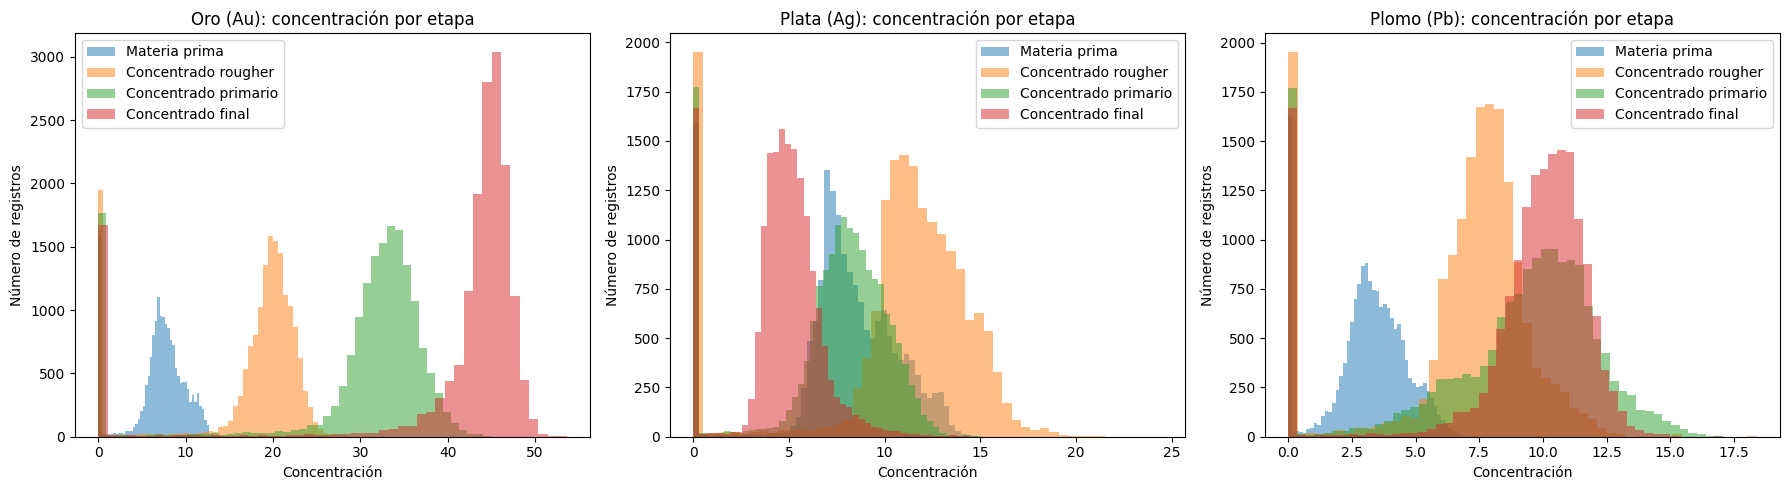

In [14]:
# Definimos las cuatro etapas por las que pasa el material y los metales a seguir
etapas = {
    'Materia prima': 'rougher.input.feed',
    'Concentrado rougher': 'rougher.output.concentrate',
    'Concentrado primario': 'primary_cleaner.output.concentrate',
    'Concentrado final': 'final.output.concentrate',
}
metales = {'au': 'Oro (Au)', 'ag': 'Plata (Ag)', 'pb': 'Plomo (Pb)'}

# Calculamos la concentración media de cada metal en cada etapa
medias_metales = pd.DataFrame()

for metal in metales:
    medias_metal = []
    for prefijo in etapas.values():
        medias_metal.append(train[prefijo + '_' + metal].mean())
    medias_metales[metales[metal]] = medias_metal

medias_metales.index = list(etapas.keys())
print(medias_metales.round(2))

# Y dibujamos la distribución de cada metal en las cuatro etapas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metal in enumerate(metales):
    ax = axes[i]
    for nombre_etapa, prefijo in etapas.items():
        ax.hist(train[prefijo + '_' + metal], bins=50, alpha=0.5, label=nombre_etapa)
    ax.set_title(metales[metal] + ': concentración por etapa')
    ax.set_xlabel('Concentración')
    ax.set_ylabel('Número de registros')
    ax.legend()

fig.tight_layout()
plt.show()

**Conclusión:** los tres metales se comportan de forma distinta a lo largo del proceso.

El **oro** sube en cada etapa sin excepción: de 7.14 en la materia prima a 17.40 en el concentrado rougher, 29.16 tras la purificación primaria y 39.47 en el concentrado final. Se multiplica por 5.5 de principio a fin, que es justo el objetivo del proceso.

La **plata** hace lo contrario a partir de la flotación: sube de 7.80 a 10.58 en el concentrado rougher y después cae a 7.42 y 4.72. La purificación la va descartando junto con el material de desecho, de modo que en el concentrado final hay menos plata que en la materia prima de partida.

El **plomo** sube hasta la purificación primaria (3.19 -> 6.88 -> 8.62) y luego se estabiliza en 9.11: la etapa secundaria ya casi no lo modifica.

En los histogramas se ve además un detalle que importa: las cuatro etapas tienen un pico de registros pegado al cero que no encaja con el resto de la distribución.

### 2.2 Compara las distribuciones del tamaño de las partículas de la alimentación

**Objetivo:** comprobar que el tamaño de partícula de la alimentación se distribuye igual en el conjunto de entrenamiento y en el de prueba. Si las distribuciones variaran significativamente, la evaluación del modelo no sería correcta.

Primero comparamoas las distribuciones con un histograma superpuesto, y después las contrasto con una prueba t de Welch sobre las medias:

- $H_0$: la media del tamaño de partícula es la misma en entrenamiento y en prueba.
- $H_1$: las medias son distintas.
- Nivel de significación: $\alpha = 0.05$.

Uso la versión de Welch ('equal_var=False') porque no hay razón para suponer que los dos conjuntos tengan la misma varianza, y de hecho el histograma sugiere que no la tienen.

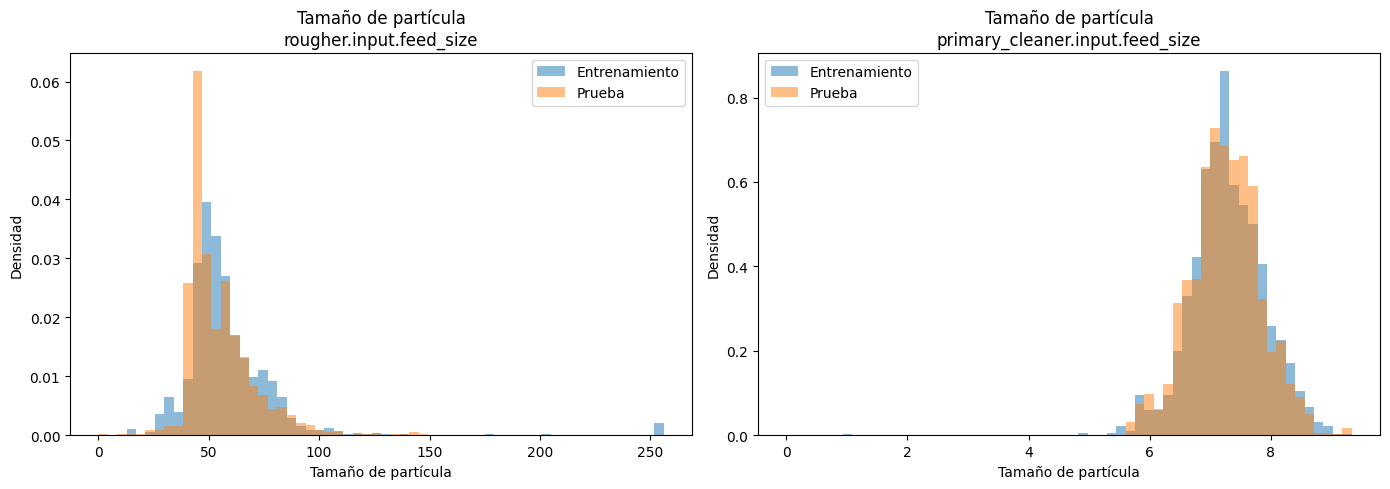

In [15]:
# Comparamos la distribución del tamaño de partícula de la alimentación entre ambos conjuntos
columnas_tamano = ['rougher.input.feed_size', 'primary_cleaner.input.feed_size']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, columna in enumerate(columnas_tamano):
    ax = axes[i]

    # recortamos la cola larga para que el gráfico sea legible
    limite = max(train[columna].quantile(0.995), test[columna].quantile(0.995))

    ax.hist(train[columna], bins=60, range=(0, limite), density=True, alpha=0.5, label='Entrenamiento')
    ax.hist(test[columna], bins=60, range=(0, limite), density=True, alpha=0.5, label='Prueba')
    ax.set_title('Tamaño de partícula\n' + columna)
    ax.set_xlabel('Tamaño de partícula')
    ax.set_ylabel('Densidad')
    ax.legend()

fig.tight_layout()
plt.show()

In [16]:
# Prueba t de Welch: no asumimos que las varianzas de los dos conjuntos sean iguales
alfa = 0.05

for columna in columnas_tamano:
    valores_train = train[columna]
    valores_test = test[columna]

    resultado = stats.ttest_ind(valores_train, valores_test, equal_var=False)

    print(columna)
    print('  entrenamiento: media', round(valores_train.mean(), 2),
          '| mediana', round(valores_train.median(), 2),
          '| desv. est.', round(valores_train.std(), 2))
    print('  prueba       : media', round(valores_test.mean(), 2),
          '| mediana', round(valores_test.median(), 2),
          '| desv. est.', round(valores_test.std(), 2))
    print('  diferencia entre las medias:', round(valores_train.mean() - valores_test.mean(), 2))
    print('  t =', round(resultado.statistic, 2), '| valor p =', resultado.pvalue)

    if resultado.pvalue < alfa:
        print('  -> rechazamos H0: las medias difieren')
    else:
        print('  -> no podemos rechazar H0')
    print()

rougher.input.feed_size
  entrenamiento: media 60.19 | mediana 54.07 | desv. est. 30.52
  prueba       : media 55.9 | mediana 49.96 | desv. est. 22.71
  diferencia entre las medias: 4.29
  t = 11.33 | valor p = 1.2417173171390233e-29
  -> rechazamos H0: las medias difieren

primary_cleaner.input.feed_size
  entrenamiento: media 7.3 | mediana 7.29 | desv. est. 0.62
  prueba       : media 7.26 | mediana 7.26 | desv. est. 0.61
  diferencia entre las medias: 0.03
  t = 3.51 | valor p = 0.0004554672200801051
  -> rechazamos H0: las medias difieren



**Conclusión:** la prueba rechaza $H_0$ en las dos columnas (t = 11.33 y t = 3.51, los dos valores p muy por debajo de 0.05), pero eso no las vuelve incomparables.

La diferencia es real y a la vez minúscula: en el primary cleaner las medias se separan 0.03 cuando la columna varía normalmente 0.62, y en el rougher son 4.29 sobre una desviación estándar de 30.52. Con más de veinte mil registros horarios, y encima correlacionados entre sí, la prueba marca como significativa cualquier diferencia por pequeña que sea.

Me quedo con lo que muestran los histogramas: las dos distribuciones se superponen casi por completo y lo único que cambia es la cola derecha del rougher, más larga en entrenamiento (30.52 contra 22.71). El conjunto de prueba no corresponde a otro régimen de operación, así que la evaluación del modelo es válida.

### 2.3 Considera las concentraciones totales de todas las sustancias en las diferentes etapas

**Objetivo:** sumar las concentraciones de las cuatro sustancias (Au + Ag + Pb + sólidos) en la materia prima, el concentrado rougher y el concentrado final, y de paso también en el concentrado primario, para ver si aparecen valores anormales en esas sumas. Si los hay, decido con los histogramas delante si vale la pena quitarlos de las dos muestras, describo lo que encuentro y aplico el filtro.

       Materia prima  Concentrado rougher  Concentrado primario  Concentrado final
count       16860.00             16860.00              16860.00           16860.00
mean           50.44                59.84                 53.67              61.19
std            18.18                24.17                 20.67              21.74
min             0.00                 0.00                  0.00               0.00
25%            50.29                61.39                 54.80              66.51
50%            55.79                68.33                 61.06              68.80
75%            60.26                73.02                 64.86              70.69
max            76.02                90.96                 76.92              80.21


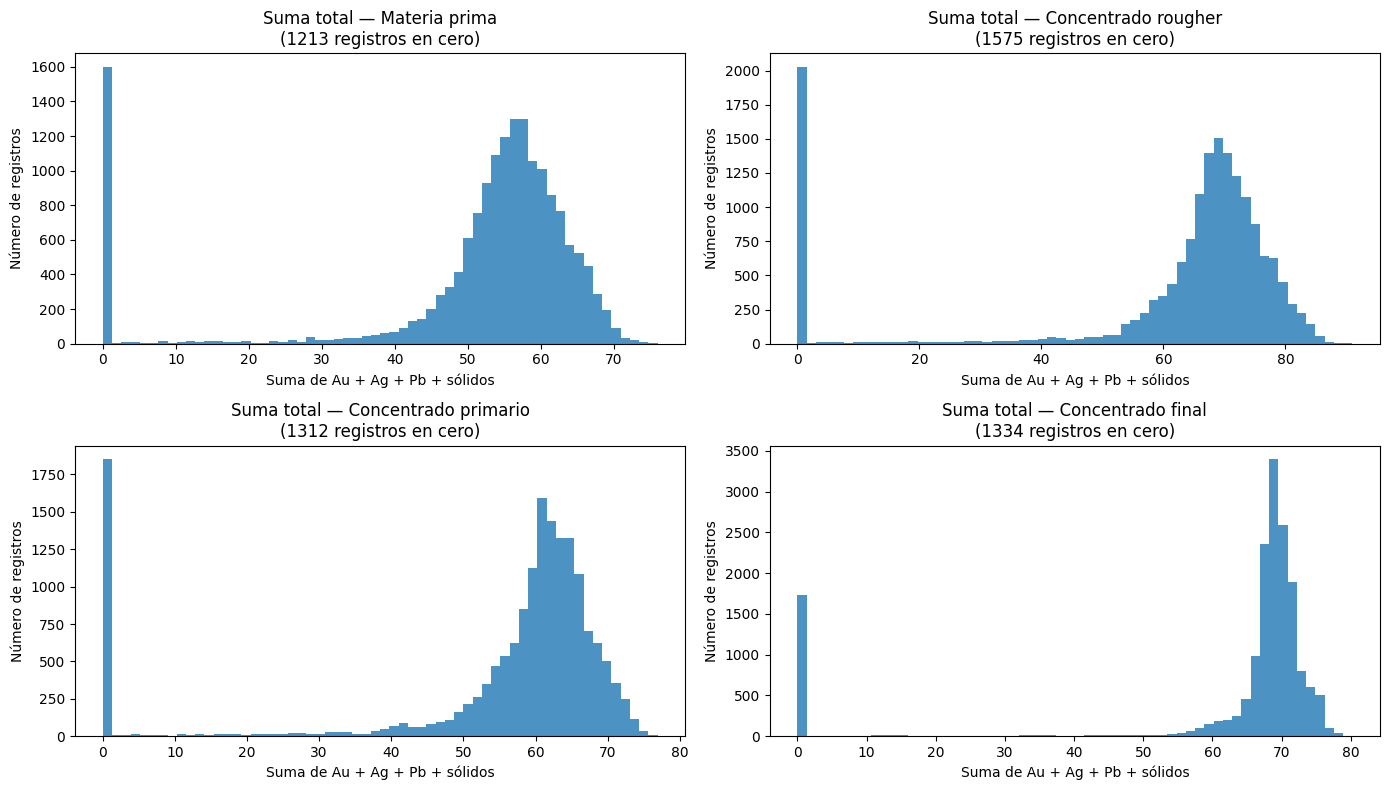

In [17]:
# Sumamos las concentraciones de los cuatro componentes en cada etapa
componentes = ['au', 'ag', 'pb', 'sol']

totales_train = pd.DataFrame()

for nombre_etapa, prefijo in etapas.items():
    columnas_etapa = []
    for componente in componentes:
        columnas_etapa.append(prefijo + '_' + componente)
    totales_train[nombre_etapa] = train[columnas_etapa].sum(axis=1)

# en prueba solo se puede calcular la materia prima
columnas_materia_prima = []
for componente in componentes:
    columnas_materia_prima.append('rougher.input.feed_' + componente)

totales_test = pd.DataFrame()
totales_test['Materia prima'] = test[columnas_materia_prima].sum(axis=1)

print(totales_train.describe().round(2))

# Dibujamos la distribución de la suma total en cada etapa
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
ejes = axes.flatten()

for i, nombre_etapa in enumerate(totales_train.columns):
    ax = ejes[i]
    ceros = (totales_train[nombre_etapa] == 0).sum()

    ax.hist(totales_train[nombre_etapa], bins=60, color='tab:blue', alpha=0.8)
    ax.set_title('Suma total — ' + nombre_etapa + '\n(' + str(ceros) + ' registros en cero)')
    ax.set_xlabel('Suma de Au + Ag + Pb + sólidos')
    ax.set_ylabel('Número de registros')

fig.tight_layout()
plt.show()

In [18]:
# ¿Cuántas filas se irían según dónde pongamos el corte?
filas_umbral = []

for umbral in [0, 1, 5, 10]:
    marca_train = (totales_train <= umbral).any(axis=1)
    marca_test = (totales_test <= umbral).any(axis=1)
    filas_umbral.append(
        {
            'umbral': umbral,
            'filas_train': marca_train.sum(),
            'pct_train': round(100 * marca_train.mean(), 2),
            'filas_test': marca_test.sum(),
            'pct_test': round(100 * marca_test.mean(), 2),
        }
    )

pd.DataFrame(filas_umbral).set_index('umbral')

,filas_train,pct_train,filas_test,pct_test
umbral,,,,
0,1866,11.07,371,6.34
1,2521,14.95,371,6.34
5,2562,15.20,377,6.44
10,2605,15.45,384,6.56


In [19]:
# Aplicamos el corte a las dos muestras: fuera los registros con alguna suma total <= 1.
# En entrenamiento se revisan las cuatro etapas, en prueba solo la materia prima, que es
# la única cuyas columnas existen en ese conjunto.
umbral_anomalias = 1

anomalas_train = (totales_train <= umbral_anomalias).any(axis=1)
anomalas_test = (totales_test <= umbral_anomalias).any(axis=1)

filas_train_antes = len(train)
filas_test_antes = len(test)

train = train[~anomalas_train].reset_index(drop=True)
test = test[~anomalas_test].reset_index(drop=True)

print('entrenamiento:', filas_train_antes, '->', len(train), 'filas (se eliminan',
      anomalas_train.sum(), ', el', round(100 * anomalas_train.mean(), 2), '%)')
print('prueba       :', filas_test_antes, '->', len(test), 'filas (se eliminan',
      anomalas_test.sum(), ', el', round(100 * anomalas_test.mean(), 2), '%)')

entrenamiento: 16860 -> 14339 filas (se eliminan 2521 , el 14.95 %)
prueba       : 5856 -> 5485 filas (se eliminan 371 , el 6.34 %)


Suma total mínima por etapa tras el filtro (entrenamiento):
Materia prima           1.62
Concentrado rougher     1.06
Concentrado primario    1.08
Concentrado final       1.07
dtype: float64

Suma total mínima en la materia prima de prueba: 1.33

rougher.output.recovery : 13646 filas utilizables
final.output.recovery : 14264 filas utilizables


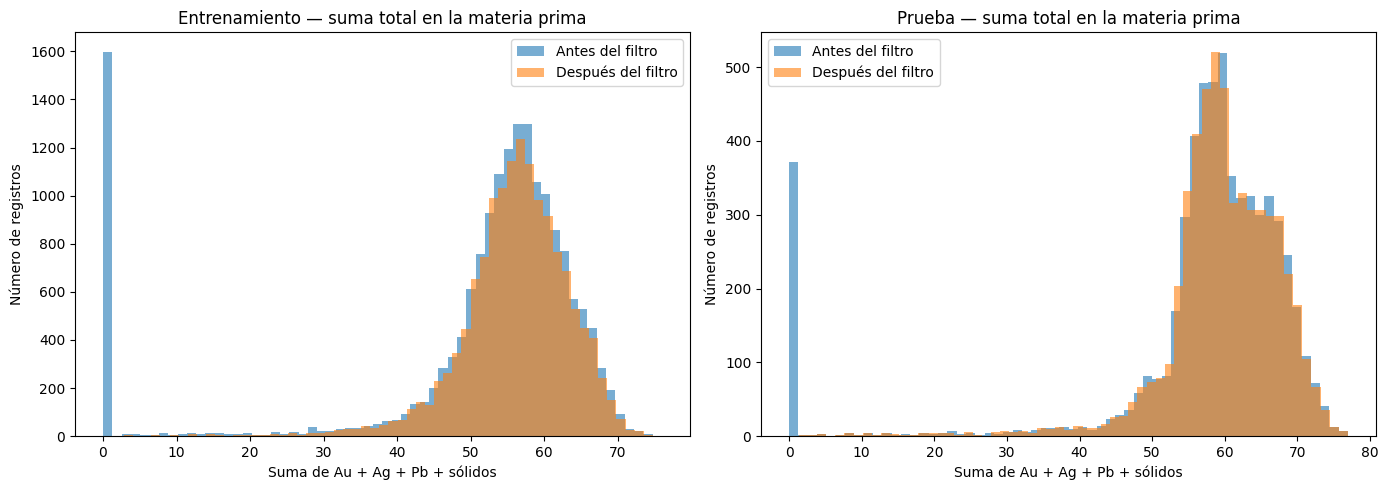

In [20]:
# Comprobamos el resultado: recalculamos las sumas sobre los datos ya limpios
totales_train_limpio = pd.DataFrame()

for nombre_etapa, prefijo in etapas.items():
    columnas_etapa = []
    for componente in componentes:
        columnas_etapa.append(prefijo + '_' + componente)
    totales_train_limpio[nombre_etapa] = train[columnas_etapa].sum(axis=1)

totales_test_limpio = pd.DataFrame()
totales_test_limpio['Materia prima'] = test[columnas_materia_prima].sum(axis=1)

print('Suma total mínima por etapa tras el filtro (entrenamiento):')
print(totales_train_limpio.min().round(2))
print()
print('Suma total mínima en la materia prima de prueba:', round(totales_test_limpio['Materia prima'].min(), 2))
print()

# ¿con cuántas filas se queda cada objetivo?
for objetivo in objetivos:
    print(objetivo, ':', train[objetivo].notna().sum(), 'filas utilizables')

# la distribución de la materia prima antes y después, para ver que solo desaparece el pico del cero
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(totales_train['Materia prima'], bins=60, alpha=0.6, label='Antes del filtro')
axes[0].hist(totales_train_limpio['Materia prima'], bins=60, alpha=0.6, label='Después del filtro')
axes[0].set_title('Entrenamiento — suma total en la materia prima')

axes[1].hist(totales_test['Materia prima'], bins=60, alpha=0.6, label='Antes del filtro')
axes[1].hist(totales_test_limpio['Materia prima'], bins=60, alpha=0.6, label='Después del filtro')
axes[1].set_title('Prueba — suma total en la materia prima')

for ax in axes:
    ax.set_xlabel('Suma de Au + Ag + Pb + sólidos')
    ax.set_ylabel('Número de registros')
    ax.legend()

fig.tight_layout()
plt.show()

**Conclusión:** sí hay valores anormales y lo mejor es quitarlos. Los histogramas de las cuatro etapas salen con dos picos: uno pegado al cero y, después de una franja casi vacía, la distribución real del proceso entre 40 y 80. Ese primer pico no es poco mineral o mineral pobre, probablemente son registros sin material. Hay 1213 ceros exactos en la materia prima, 1575 en el concentrado rougher, 1312 en el primario y 1334 en el final.

Puse el umbral en 1 después de mirar la tabla de cortes. Entre 0 y 1 hay 655 filas que un corte estricto en cero dejaría dentro, y son la misma anomalía con algo de ruido de medición encima. De 1 a 10 solo se mueven 84 filas más, así que ahí la curva ya está plana y cualquier valor de ese rango daría prácticamente el mismo resultado.

Con el filtro aplicado, el entrenamiento baja de 16860 a **14339 filas** (2521 menos, el 14.95 %) y la prueba de 5856 a **5485** (371 filas, el 6.34 %). Las sumas mínimas que quedan son 1.62 en la materia prima del entrenamiento y 1.33 en la de prueba, o sea que ya no hay ningún registro vacío. La media de la suma total en la materia prima sube de 50.44 a 56.07, que es el valor de la planta cuando de verdad está operando, y en los histogramas de después se ve que solo desaparece la barra del cero: el resto de la distribución queda igual.

Los objetivos se quedan con 13646 filas utilizables en 'rougher.output.recovery' y 14264 en 'final.output.recovery'.

## 3. Construcción del modelo

### 3.1 Escribe una función para calcular el valor final de sMAPE

**Objetivo:** implementar la métrica con la que se evalúa el proyecto y comprobarla con casos de los que ya conozco la respuesta.

In [21]:
def smape(y_real, y_pred):
    """Error porcentual absoluto medio simétrico, expresado en porcentaje."""
    y_real = np.array(y_real, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    numerador = np.abs(y_real - y_pred)
    denominador = (np.abs(y_real) + np.abs(y_pred)) / 2

    # si el valor real y el predicho son ambos cero no hay error, y además
    # no podemos dividir: dejamos esos casos en cero
    errores = np.zeros(len(y_real))
    hay_denominador = denominador != 0
    errores[hay_denominador] = numerador[hay_denominador] / denominador[hay_denominador]

    return 100 * errores.mean()


def smape_final(smape_rougher, smape_purificacion):
    """sMAPE final: la flotación pesa un 25 % y la purificación un 75 %."""
    return 0.25 * smape_rougher + 0.75 * smape_purificacion


# Comprobamos la función con casos de resultado conocido
print('predicción idéntica     :', smape([1, 2, 3], [1, 2, 3]))
print('real y predicho en cero :', smape([0, 0], [0, 0]))
print('predice 0 con real 100  :', smape([100.0], [0.0]))
print('simetría 10 vs 12       :', round(smape([10], [12]), 4), '=', round(smape([12], [10]), 4))
print('sMAPE final de ejemplo  :', smape_final(4.0, 8.0))

predicción idéntica     : 0.0
real y predicho en cero : 0.0
predice 0 con real 100  : 200.0
simetría 10 vs 12       : 18.1818 = 18.1818
sMAPE final de ejemplo  : 7.0


**Conclusión:** la función responde como se esperaba. Con predicciones idénticas a los valores reales da 0. Cuando el real y el predicho son los dos cero devuelve 0 en vez de dividir entre cero, predecir 0 cuando el real es 100 da 200, que es el tope que puede alcanzar el sMAPE.
Y es simétrica, porque confundir 10 con 12 penaliza igual que confundir 12 con 10 (18.18 en los dos casos). Esa es la diferencia con el MAPE.

'smape_final' aplica la ponderación que pide el enunciado: con 4.0 en la flotación y 8.0 en la purificación devuelve 7.0, así que la etapa final pesa el triple.

### 3.2 Entrena diferentes modelos

**Objetivo:** entrenar varios modelos, evaluarlos con validación cruzada, quedarme con el mejor y probarlo contra la muestra de prueba.

Comparo una línea base (predecir siempre la mediana), una regresión lineal, dos árboles de decisión y tres bosques aleatorios de distinta profundidad. Cada objetivo se entrena por separado con todas las filas en las que está medido, y las únicas entradas son las 52 características comunes.

La validación cruzada la hago con 'KFold' de dos maneras:

- 'KFold(shuffle=True)', que reparte las filas al azar entre los 5 bloques.
- 'KFold(shuffle=False)', que las deja en el orden en que vienen, de forma que cada bloque de validación es un tramo continuo de tiempo.

Pruebo las dos porque, como vi en el punto 1, los registros son horarios y consecutivos, y la medición de una hora se parece muchísimo a la de la hora anterior. Si barajo las filas, una que cae en validación tiene a sus vecinas inmediatas dentro del entrenamiento y el modelo puede reconocerla casi de memoria en vez de predecirla

Comparando las dos versiones puedo ver qué parte de la puntuación es aprendizaje y qué parte es esa filtración temporal.

In [22]:
# Los modelos que vamos a comparar.
modelos = {
    'Línea base (mediana)': DummyRegressor(strategy='median'),
    'Regresión lineal': LinearRegression(),
    'Árbol de decisión (prof. 5)': DecisionTreeRegressor(max_depth=5, random_state=12345),
    'Árbol de decisión (prof. 10)': DecisionTreeRegressor(max_depth=10, random_state=12345),
    'Bosque aleatorio (50 árb., prof. 3)': RandomForestRegressor(n_estimators=50, max_depth=3, random_state=12345, n_jobs=-1),
    'Bosque aleatorio (50 árb., prof. 10)': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=12345, n_jobs=-1),
    'Bosque aleatorio (50 árb., prof. 15)': RandomForestRegressor(n_estimators=50, max_depth=15, random_state=12345, n_jobs=-1),
}

# El mismo KFold de dos maneras: barajando las filas y respetando el orden temporal
esquemas = {
    'KFold barajado': KFold(n_splits=5, shuffle=True, random_state=12345),
    'KFold sin barajar': KFold(n_splits=5, shuffle=False),
}

# el sMAPE es un error: cuanto más bajo mejor, por eso greater_is_better=False
evaluador = make_scorer(smape, greater_is_better=False)

resultados_cv = []

for nombre_modelo in modelos:
    modelo = modelos[nombre_modelo]
    fila = {'modelo': nombre_modelo}

    for nombre_esquema in esquemas:
        esquema = esquemas[nombre_esquema]

        # evaluamos cada objetivo por separado y luego los combinamos
        smape_rougher = 0
        smape_purificacion = 0

        for objetivo in objetivos:
            # cada objetivo usa todas las filas en las que está medido
            marca = train[objetivo].notna()
            X = train.loc[marca, comunes]
            y = train.loc[marca, objetivo]

            puntajes = cross_val_score(modelo, X, y, cv=esquema, scoring=evaluador)
            promedio = -puntajes.mean()

            if objetivo == 'rougher.output.recovery':
                smape_rougher = promedio
            else:
                smape_purificacion = promedio

        fila[nombre_esquema] = smape_final(smape_rougher, smape_purificacion)

    resultados_cv.append(fila)

tabla_cv = pd.DataFrame(resultados_cv).set_index('modelo')
tabla_cv.round(3)

,KFold barajado,KFold sin barajar
modelo,,
Línea base (mediana),9.528,9.815
Regresión lineal,7.357,10.223
Árbol de decisión (prof. 5),7.231,10.442
Árbol de decisión (prof. 10),6.640,13.140
"Bosque aleatorio (50 árb., prof. 3)",7.504,8.642
"Bosque aleatorio (50 árb., prof. 10)",5.759,8.942
"Bosque aleatorio (50 árb., prof. 15)",5.306,9.073


**Resultados de la validación cruzada:** 
Barajando, el sMAPE final mejora cuanto más complejo es el modelo: 9.528 la línea base, 7.357 la regresión lineal, 6.640 el árbol de profundidad 10 y 5.306 el bosque de profundidad 15, que sería el ganador. Leído así parecería que el bosque profundo baja el error casi a la mitad frente a no tener modelo.

Sin barajar, el cuadro cambia por completo. La línea base marca 9.815 y por debajo de ella quedan la regresión lineal (10.223), el árbol de profundidad 5 (10.442) y el de profundidad 10 (13.140): valen menos que predecir siempre la mediana. Entre los tres bosques, el mejor pasa a ser el más simple, el de profundidad 3 con 8.642, seguido del de profundidad 10 (8.942) y del de profundidad 15 (9.073). El orden entre ellos se invierte respecto al esquema barajado.

Es lo que pensaba al plantear los dos esquemas. Al barajar registros horarios consecutivos, cada fila de validación tiene a sus vecinas dentro del entrenamiento, y un modelo se las aprende. Cuanta más profundidad, más las memoriza y mejor parece la puntuación, así que el esquema barajado termina premiando a los modelos que peor generalizan. Cuando los bloques de validación son períodos enteros que el modelo no ha visto, ese atajo desaparece y queda a la vista el sobreajuste. El caso más claro es el árbol de profundidad 10: pasa de 6.640 a 13.140, el doble de error.

Me quedo entonces con el bosque aleatorio de 50 árboles y profundidad 3. Es el mejor bajo la validación que respeta el orden temporal, y su poca profundidad es lo que le impide agarrarse al ruido de corto plazo. En la prueba final llevo también el bosque de profundidad 15, para ver cuál de los dos esquemas estaba estimando bien.

In [23]:
# El conjunto de prueba no trae los objetivos: los recuperamos del conjunto fuente por fecha
test_con_objetivos = test.merge(full[['date'] + objetivos], on='date', how='left')

for objetivo in objetivos:
    print(objetivo, ':', test_con_objetivos[objetivo].notna().sum(),
          'de', len(test_con_objetivos), 'filas de prueba con objetivo')
print()

# Entrenamos con todo el conjunto de entrenamiento y evaluamos sobre la muestra de prueba
finalistas = {
    'Línea base (mediana)': DummyRegressor(strategy='median'),
    'Bosque prof. 3 (elige el KFold sin barajar)': RandomForestRegressor(n_estimators=50, max_depth=3, random_state=12345, n_jobs=-1),
    'Bosque prof. 15 (elige el KFold barajado)': RandomForestRegressor(n_estimators=50, max_depth=15, random_state=12345, n_jobs=-1),
}

resultados_prueba = []

for nombre_modelo in finalistas:
    modelo = finalistas[nombre_modelo]
    smape_rougher = 0
    smape_purificacion = 0

    for objetivo in objetivos:
        # entrenamos con las filas de entrenamiento que tienen ese objetivo medido
        marca_train = train[objetivo].notna()
        X_train = train.loc[marca_train, comunes]
        y_train = train.loc[marca_train, objetivo]
        modelo.fit(X_train, y_train)

        # y evaluamos sobre las filas de prueba que tienen ese objetivo medido
        marca_test = test_con_objetivos[objetivo].notna()
        X_test = test_con_objetivos.loc[marca_test, comunes]
        y_test = test_con_objetivos.loc[marca_test, objetivo]
        predicciones = modelo.predict(X_test)

        if objetivo == 'rougher.output.recovery':
            smape_rougher = smape(y_test, predicciones)
        else:
            smape_purificacion = smape(y_test, predicciones)

    resultados_prueba.append(
        {
            'modelo': nombre_modelo,
            'sMAPE rougher': smape_rougher,
            'sMAPE purificación': smape_purificacion,
            'sMAPE final': smape_final(smape_rougher, smape_purificacion),
        }
    )

tabla_prueba = pd.DataFrame(resultados_prueba).set_index('modelo')
tabla_prueba.round(3)

rougher.output.recovery : 5310 de 5485 filas de prueba con objetivo
final.output.recovery : 5414 de 5485 filas de prueba con objetivo



,sMAPE rougher,sMAPE purificación,sMAPE final
modelo,,,
Línea base (mediana),8.675,10.654,10.159
Bosque prof. 3 (elige el KFold sin barajar),8.525,10.250,9.819
Bosque prof. 15 (elige el KFold barajado),7.963,11.015,10.252


**Conclusión:** de las 5485 filas de prueba, 5310 tienen medida la recuperación del rougher y 5414 la final. El resto se queda fuera de la evaluación porque no hay valor real con el que comparar.

El modelo elegido cumple: 9.819 de sMAPE final contra 10.159 de la línea base, una mejora del 3.3 % sobre datos que nunca vio. Es una mejora modesta porque predecir la recuperación solo con los parámetros de operación tiene un techo bajo: las variables que de verdad la determinan, las concentraciones de salida, son las que no están disponibles en el momento de predecir.

La comparación entre los tres modelos confirma la decisión del punto anterior. El bosque de profundidad 15, que con el 'KFold' barajado quedaba primero con 5.306, saca 10.252 en la prueba, peor que la línea base. El esquema barajado no solo falló en la cifra (5.306 contra 10.252, casi el doble), sino que además señaló a un modelo que vale menos que no modelar.

El 'KFold' sin barajar tampoco acierta la cifra exacta: predijo 8.642 para el bosque de profundidad 3 y 9.073 para el de 15, y en la prueba salieron 9.819 y 10.252. Pero se equivoca de una forma mucho más útil, porque se queda corto en 1.18 puntos en los dos casos por igual (0.43 previsto contra 0.43 real). Importa menos acertar el número absoluto que ordenar bien a los candidatos.

Hay un detalle que me llamó la atención: el bosque profundo es el mejor de los tres en la etapa rougher (7.963) y el peor en la purificación (11.015). Como el sMAPE final pondera la purificación al 75 %, pierde. Usar un modelo distinto para cada objetivo, más profundidad en el rougher y menos en la etapa final, probablemente rendiría algo mejor que la misma configuración para los dos.

## Conclusiones generales

Los datos venían bien construidos, pero no limpios. La fórmula de recuperación del dataset es correcta: el EAM entre mi cálculo y la columna del archivo es de 9.21e-15 y donde el cálculo no está definido el propio archivo deja el valor ausente, sin inconsistencias. Lo que sí hubo que arreglar fueron los valores ausentes, que aparecen en 85 de las 87 columnas, y unos 2500 registros de planta parada con las concentraciones totales en cero.

Los ausentes los rellené en orden temporal ('ffill' + 'bfill') en lugar de eliminar filas: eran el 1.44 % de las celdas pero tocaban casi el 20 % de las filas, y borrarlas habría recortado el conjunto de prueba, que es contraproducente para la evaluación. Las anomalías sí las eliminé, con el umbral en 1 fijado sobre el histograma. El entrenamiento quedó en 14339 filas y la prueba en 5485.

El conjunto de prueba resultó comparable al de entrenamiento. La prueba t de Welch rechaza la igualdad de medias en el tamaño de partícula, pero las diferencias son diminutas al lado de la variación de los datos (0.03 unidades de separación sobre una desviación estándar de 0.62 en el primary cleaner) y los histogramas de los dos conjuntos se superponen casi por completo. Con más de veinte mil observaciones, la prueba marca como significativa cualquier diferencia mínima. El tamaño de esa diferencia dice que no importa, y por eso doy la evaluación por válida.

Para mí lo más interesante del proyecto no terminó siendo el modelo, sino la forma en que lo pude validar. Con 'KFold' barajado, el bosque de profundidad 15 marcaba 5.306 de sMAPE final y parecía el mejor de todos. En la prueba real obtuvo 10.252, peor que predecir siempre la mediana. La causa es la estructura "temporal" de los datos. Son mediciones horarias consecutivas, y al barajar, cada fila de validación queda pegada a sus vecinas dentro del entrenamiento. El mismo 'KFold' sin barajar, con los bloques de validación como tramos continuos de tiempo, invierte el orden de los modelos y señala al bosque de profundidad 3, que es el que efectivamente gana en la prueba.

**Modelo final**: bosque aleatorio de 50 árboles y profundidad 3, con un sMAPE final de 9.819 en la muestra de prueba, frente a 10.159 de la línea base. La mejora es del 3.3 %: modesta, pero real y medida sobre datos que el modelo no había visto. La alternativa que sugería el 'KFold' barajado habría sido peor que no modelar.